In [1]:
import json
import os
from pathlib import Path
from pprint import pprint
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

dirpath_repo_root = Path().resolve().parents[1]
dirpath_self = Path().resolve().parent
sys.path.append(str(dirpath_repo_root))
sys.path.append(str(dirpath_self))

from analysis.ou_tuning import batch_utils

In [2]:
def _get_fpath_by_templ(dirpath: Path, fname_templ: str) -> str:
    files = list(dirpath.glob(fname_templ))
    if len(files) != 1:
        print(f'Path for search: {str(dirpath)}')
        print(f'Name template: {fname_templ}')
        raise RuntimeError('Should be exactly one filename match')
    return files[0]

### 1D batch (rxe)

In [12]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/it2_nosub_wmult_var_rxe'
exp_name_sub = 'exp_IT2_t_3.0_5.0_rxi_10000.0_wx_0.1_0.1_wmult_0.25'

dirpath_res = dirpath_repo_root / 'exp_results' / exp_name

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'rxe': 'rxe'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
#job_idx_xr

In [ ]:
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'
    
# Test: find the data file for job_id=0a
fname_data = fname_data_templ.format(job=0)
fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)   # resolve * in fname_data
fpath_data.name

'result_00000_rxe_10000.0.json'

In [14]:
pops_used = ['IT2', 'IT6frz']
vars = {'rate': 'rates', 'cv': 'cvs'}

dims_new = list(job_idx_xr.dims) + ['pop']
coords_new = dict(job_idx_xr.coords) | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)
#X

In [15]:
# Iterate over all cells in job_idx_xr
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}

    # Load data and assign it to the corresponding slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]

Text(0.5, 1.0, 'CV, IT2')

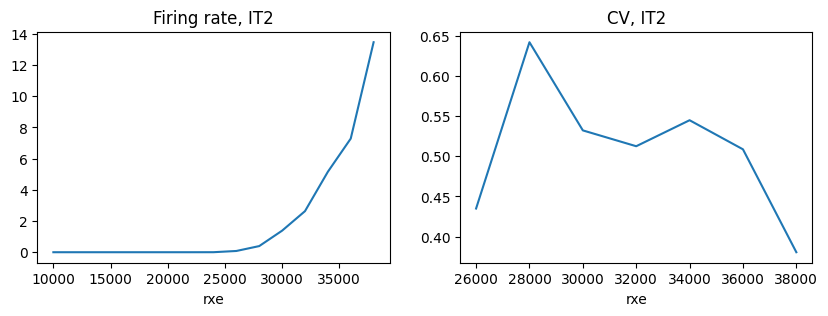

In [16]:
pop = pops_used[0]
r = X['rate'].sel(pop=pop)
cv = X['cv'].sel(pop=pop)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(r.rxe, r)
plt.xlabel('rxe')
plt.title(f'Firing rate, {pop}')
plt.subplot(1, 2, 2)
plt.plot(r.rxe, cv)
plt.xlabel('rxe')
plt.title(f'CV, {pop}')

### 2D batch (drxe, rxi)

In [3]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/pops_inpsur_newsec_var_drxe_rxi'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it2_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['IT2']
#exp_label = 'it2'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_it6_sz_5_5_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['IT6']
#exp_label = 'it6'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_it4_sz_5_5_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['ITP4', 'ITS4']
#exp_label = 'it4'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_ct_sz_5_5_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['CT5A', 'CT5B', 'CT6']
#exp_label = 'ct'

exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it5_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
pops_used = ['IT5A', 'IT5B']
exp_label = 'it5'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_pt5b_sz_5_5_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pt5b_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['PT5B']
#exp_label = 'pt5b'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pv_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
#exp_label = 'pv'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_som_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_som_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
#exp_label = 'som'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_vip_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_vip_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
#exp_label = 'vip'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_ngf_sz_5_5_t_3.0_5.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_ngf_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']
#exp_label = 'ngf'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_it3_sz_5_5_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it3_sz_20_20_t_7.0_12.0_wx_psp_0.5_wmult_0.25_ee_0.5_lsec_0_xsec_soma_soma'
#pops_used = ['IT3']
#exp_label = 'it3'

dirpath_cfg = dirpath_repo_root / 'exp_configs' / exp_name
dirpath_res = dirpath_repo_root / 'exp_results' / exp_name
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'drxe_pos': 'drxe_num', 'rxi_pos': 'rxi_num'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
job_idx_xr

<xarray.DataArray 'job_id' (drxe_pos: 20, rxi_pos: 20)> Size: 3kB
array([[ nan,  nan,  nan,  nan,  80., 100., 120., 140., 160., 180., 200.,
        220., 240., 260., 280., 300., 320., 340., 360., 380.],
       [ nan,  nan,  nan,  nan,  81., 101., 121., 141., 161., 181., 201.,
        221., 241., 261., 281., 301., 321., 341., 361., 381.],
       [ nan,  nan,  nan,  nan,  82., 102., 122., 142., 162., 182., 202.,
        222., 242., 262., 282., 302., 322., 342., 362., 382.],
       [ nan,  nan,  nan,  63.,  83., 103., 123., 143., 163., 183., 203.,
        223., 243., 263., 283., 303., 323., 343., 363., 383.],
       [ nan,  nan,  nan,  64.,  84., 104., 124., 144., 164., 184., 204.,
        224., 244., 264., 284., 304., 324., 344., 364., 384.],
       [ nan,  nan,  nan,  65.,  85., 105., 125., 145., 165., 185., 205.,
        225., 245., 265., 285., 305., 325., 345., 365., 385.],
       [ nan,  nan,  nan,  66.,  86., 106., 126., 146., 166., 186., 206.,
        226., 246., 266., 286., 306., 326., 346., 366., 386.],
       [ nan,  nan,  47.,  67.,  87., 107., 127., 147., 167., 187., 207.,
        227., 247., 267., 287., 307., 327., 347., 367., 387.],
       [ nan,  nan,  48.,  68.,  88., 108., 128., 148., 168., 188., 208.,
        228., 248., 268., 288., 308., 328., 348., 368., 388.],
       [ nan,  nan,  49.,  69.,  89., 109., 129., 149., 169., 189., 209.,
        229., 249., 269., 289., 309., 329., 349., 369., 389.],
       [ nan,  30.,  50.,  70.,  90., 110., 130., 150., 170., 190., 210.,
        230., 250., 270., 290., 310., 330., 350., 370., 390.],
       [ nan,  31.,  51.,  71.,  91., 111., 131., 151., 171., 191., 211.,
        231., 251., 271., 291., 311., 331., 351., 371., 391.],
       [ nan,  32.,  52.,  72.,  92., 112., 132., 152., 172., 192., 212.,
        232., 252., 272., 292., 312., 332., 352., 372., 392.],
       [ nan,  33.,  53.,  73.,  93., 113., 133., 153., 173., 193., 213.,
        233., 253., 273., 293., 313., 333., 353., 373., 393.],
       [ 14.,  34.,  54.,  74.,  94., 114., 134., 154., 174., 194., 214.,
        234., 254., 274., 294., 314., 334., 354., 374., 394.],
       [ 15.,  35.,  55.,  75.,  95., 115., 135., 155., 175., 195., 215.,
        235., 255., 275., 295., 315., 335., 355., 375., 395.],
       [ 16.,  36.,  56.,  76.,  96., 116., 136., 156., 176., 196., 216.,
        236., 256., 276., 296., 316., 336., 356., 376., 396.],
       [ 17.,  37.,  57.,  77.,  97., 117., 137., 157., 177., 197., 217.,
        237., 257., 277., 297., 317., 337., 357., 377., 397.],
       [ 18.,  38.,  58.,  78.,  98., 118., 138., 158., 178., 198., 218.,
        238., 258., 278., 298., 318., 338., 358., 378., 398.],
       [ 19.,  39.,  59.,  79.,  99., 119., 139., 159., 179., 199., 219.,
        239., 259., 279., 299., 319., 339., 359., 379., 399.]])
Coordinates:
  * drxe_pos  (drxe_pos) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * rxi_pos   (rxi_pos) int64 160B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19

In [4]:
vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    #'vavg': 'v_med_avg'
    'vavg': 'v_thresh_avg', 'vstd': 'v_thresh_std'
}

# Load (drxe, rxi) regions
fname_rgn = dirpath_cfg / 'regions' / f'regions_{exp_label}.json'
with open(fname_rgn, 'r') as fid:
    regions = json.load(fid)['regions']

n_drxe = job_idx_xr.sizes['drxe_pos']
n_rxi = job_idx_xr.sizes['rxi_pos']

X = {}
for pop in pops_used:
    # Create a Dataset
    X_ = {}
    for v in vars:
        X_[v] = xr.full_like(job_idx_xr, np.nan, dtype=np.float64)
    X_ = xr.Dataset(X_)

    # Region
    rgn = regions[pop]
    rxe0, rxi0 = rgn['rxe0'], rgn['rxi0']
    drxe, drxi = rgn['drxe'], rgn['drxi']
    drxe_vals = np.linspace(-drxe, 0, n_drxe)
    rxi_vals = np.linspace(rxi0, rxi0 + drxi, n_rxi)

    # Add drxe and rxi coords
    X_ = X_.assign_coords(
        drxe=('drxe_pos', drxe_vals),
        rxi=('rxi_pos', rxi_vals),
    )
    
    X[pop] = X_

In [5]:
# Iterate over all cells in job_idx_xr and fill X
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    if np.isnan(job_id):
        continue
    job_id = int(job_id)
    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    # Load data and assign it to the corresponding slices in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            if pop in res[v_res]:
                X[pop][v][sel] = res[v_res][pop]

for pop in pops_used:
    X[pop] = X[pop].swap_dims({
        'drxe_pos': 'drxe',
        'rxi_pos': 'rxi',
    })

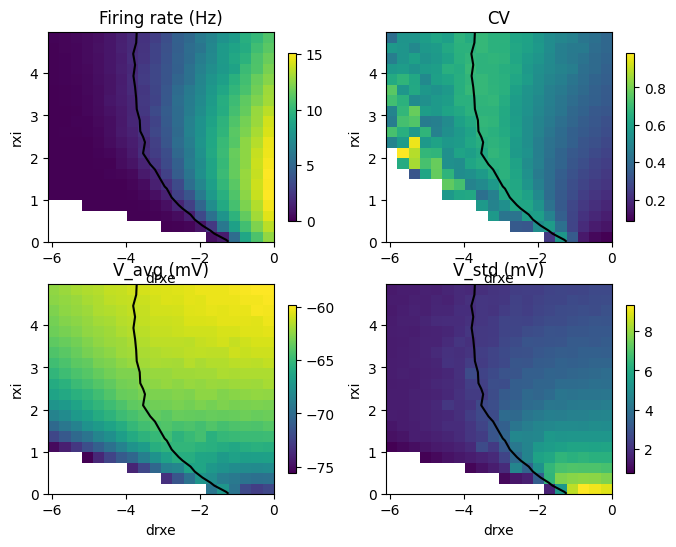

In [6]:
def plot_2d_maps(pop, r0):

    r, cv = X[pop]['rate'], X[pop]['cv']
    vmin, vmax = X[pop]['vmin'], X[pop]['vmax']
    vavg, vstd = X[pop]['vavg'], X[pop]['vstd']

    plots = [
        ("Firing rate (Hz)", r),
        ("CV", cv),
        #("Vmin (mV)", vmin),
        #("Vmax (mV)", vmax),
        ("V_avg (mV)", vavg),
        ("V_std (mV)", vstd)
    ]

    k = 1e-3   # for visualization
    x0, x1 = float(r.drxe.min()) * k, float(r.drxe.max()) * k
    y0, y1 = float(r.rxi.min()) * k, float(r.rxi.max()) * k

    fig, axs = plt.subplots(2, 2, figsize=(8, 6))

    for ax, (title, da) in zip(axs.ravel(), plots):
        im = ax.imshow(
            da.T, extent=(x0, x1, y0, y1),
            aspect='auto', origin='lower',
            #interpolation='nearest'
        )
        ax.set_title(title)
        ax.set_xlabel('drxe')
        ax.set_ylabel('rxi')
        fig.colorbar(im, ax=ax, shrink=0.8)

        for r0_ in r0:
            ax.contour(
                r.drxe * k, r.rxi * k, (r - r0_).T,
                [0], colors='k'
            )

    """ rxi1, rxi2 = r.rxi.item(0), r.rxi.item(-1)
    rxe1 = r.isel(rxi=0).idxmax(dim='rxe').item()
    rxe2 = r.isel(rxi=-1).idxmax(dim='rxe').item()
    q1 = (rxe2 - rxe1) / (rxi2 - rxi1) * 1.1
    q0 = rxe1 - rxi1 * q1

    rxi_ = r.rxi.values
    rxe_ = q0 + rxi_ * q1
    #axs[0, 0].plot(rxe_ * k, rxi_ * k, 'k')

    print(f'{pop}:')
    #print(f'q0 = {q0}')
    #print(f'q1 = {q1}') """

pop = pops_used[0]
plot_2d_maps(pop, r0=[2])

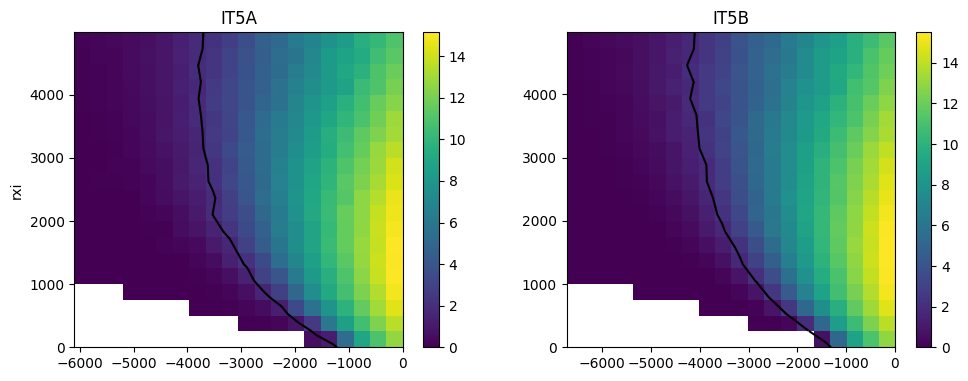

In [7]:
xname, yname = 'drxe', 'rxi'
k = 1

plt.figure(figsize=(18, 9))

for n, pop in enumerate(pops_used):
    X_ = X[pop]

    x0, x1 = float(X_[xname].min()) * k, float(X_[xname].max()) * k
    y0, y1 = float(X_[yname].min()) * k, float(X_[yname].max()) * k

    r = X_['rate']
    #r.values[np.isnan(r)] = 0

    plt.subplot(2, 3, n + 1)
    plt.imshow(r.T, extent=(x0, x1, y0, y1),
               aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar()
    plt.title(pop)
    if n in [3, 4, 5]:
        plt.xlabel(xname)
    if n in [0, 3]:
        plt.ylabel(yname)

    r0 = 2
    cc = plt.contour(r.drxe * k, r.rxi * k, (r - r0).T, [0], colors='k')

In [8]:
drxe, rxi = cc.allsegs[0][0][-1, :]
drxe, rxi

(np.float64(-1313.639862224609), np.float64(0.0))

In [9]:
X_ = X['IT2']
ind_e = np.argmin(np.abs(X_.coords['drxe'].values - drxe)).item()
ind_i = np.argmin(np.abs(X_.coords['rxi'].values - rxi)).item()
job_id = job_idx_xr.sel(drxe_pos=ind_e, rxi_pos=ind_i).item()
#ind_e, ind_i
job_id

KeyError: 'IT2'

In [ ]:
X_['rate'].isel(drxe=ind_e, rxi=ind_i).item()

NameError: name 'ind_e' is not defined

In [ ]:
rgn = regions['IT2']
rxe0, rxi0 = rgn['rxe0'], rgn['rxi0']
drxe_l, rxi_l = rgn['drxe'], rgn['drxi']
k = rgn['rxi_rxe_slope']

rxe1 = rxe0 + (rxi - rxi0) / k
rxe_vals = np.linspace(rxe1 - drxe_l, rxe1, 20)
rxe = rxe_vals[ind_e]
rxe

np.float64(4611.578947368422)

In [ ]:
rxe = rxe0 + (rxi - rxi0) / k + drxe
rxe

np.float64(4456.98284708987)

In [10]:
def upsample_and_smooth(da, sz, win):
    da_up = da.interp(**sz)

    mask0 = da.notnull()
    mask_up = (
        mask0.astype(float)
        .interp(**sz, method='nearest')
        .astype(bool)
    )

    num = da_up.fillna(0).rolling(**win, center=True, min_periods=1).sum()
    den = da_up.notnull().astype(float).rolling(**win, center=True, min_periods=1).sum()

    out = num / den
    out = out.where(mask_up)

    return out

In [11]:
pop = pops_used[0]
X_ = X[pop]

x0, x1 = float(X_[xname].min()) * k, float(X_[xname].max()) * k
y0, y1 = float(X_[yname].min()) * k, float(X_[yname].max()) * k

vars_used = ['rate', 'cv', 'vmin', 'vmax', 'vavg', 'vstd']
X_ = [X_[v] for v in vars_used]

N = 200

drxe_new = np.linspace(x0, x1, N)
rxi_new  = np.linspace(y0, y1, N)
sz = {xname: drxe_new, yname: rxi_new}

w = 71
win = {xname: w, yname: w}

X_ = [upsample_and_smooth(x_, sz, win) for x_ in X_]

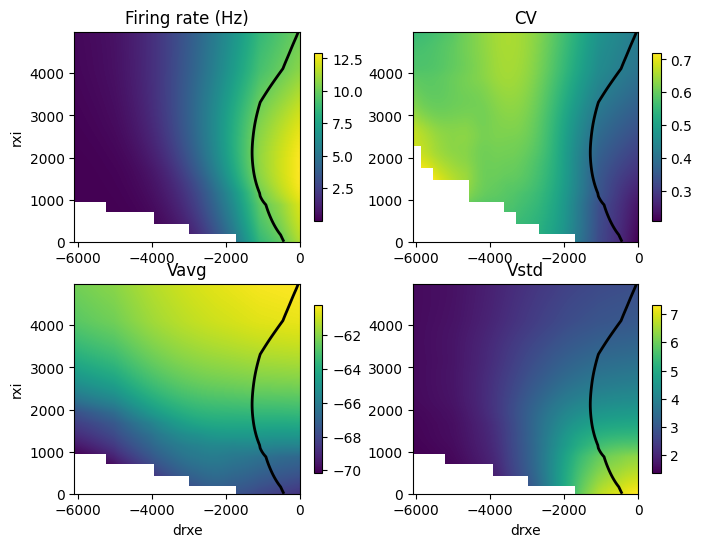

In [12]:
r, cv, vmin, vmax, vavg, vstd = X_

# Rate data used for contour selection
x_coords = r[xname].values * k
y_coords = r[yname].values * k
Xg, Yg = np.meshgrid(x_coords, y_coords)
Z = np.ma.masked_invalid(r.values.T)  # match imshow transpose, mask NaNs

# Contour level
r0 = 10

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
plots = [
    ("Firing rate (Hz)", r),
    ("CV", cv),
    #("Vmin (mV)", vmin),
    #("Vmax (mV)", vmax),
    ("Vavg", vavg),
    ("Vstd", vstd)
]

for ax, (title, da) in zip(axs.ravel(), plots):
    # Metric heatmap
    im = ax.imshow(
        da.T, extent=(x0, x1, y0, y1),
        aspect='auto', origin='lower',
        #interpolation='nearest'
        interpolation='bicubic'
    )

    # Contour: r=r0
    cs = ax.contour(Xg, Yg, Z, levels=[r0], colors='k', linewidths=2)
    #ax.clabel(cs, fmt={r0: f"r={r0} Hz"}, inline=True, fontsize=8)

    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)

for n in range(2):
    axs[1, n].set_xlabel('drxe')
    axs[n, 0].set_ylabel('rxi')


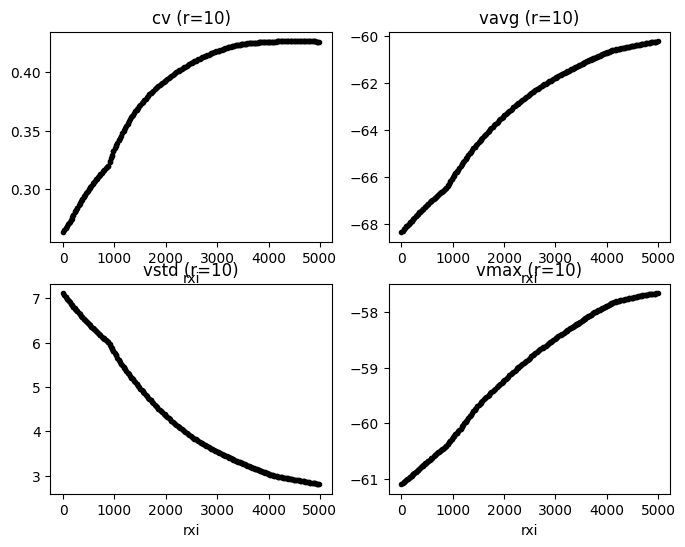

In [13]:
from scipy.interpolate import RegularGridInterpolator

Y_vars = {'cv': cv, 'vavg': vavg, 'vstd': vstd, 'vmax': vmax}
          #'vmin': vmin, 'vmax': vmax}

plt.figure(figsize=(8, 6))

Yc = {}
Ric = {}

for n, (v, Y_) in enumerate(Y_vars.items()):

    Y = np.array(Y_.values.T, dtype=float)
    interp = RegularGridInterpolator(
        (y_coords, x_coords), Y,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    
    plt.subplot(2, 2, n + 1)

    #Yc[v] = 
    for cont in cs.allsegs[0]:
        drxe_c = cont[:, 0]
        rxi_c  = cont[:, 1]
        Yc_ = interp(np.c_[rxi_c, drxe_c])
        plt.plot(rxi_c, Yc_, 'k.')

    plt.xlabel('rxi')
    plt.title(f'{v} (r={r0})')

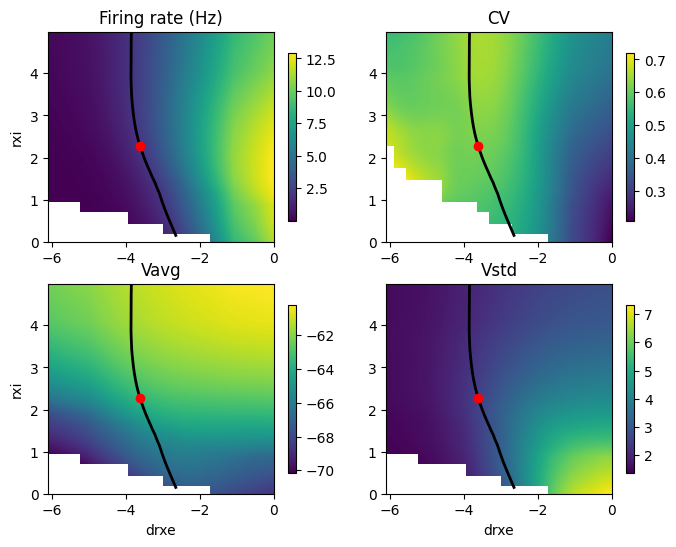

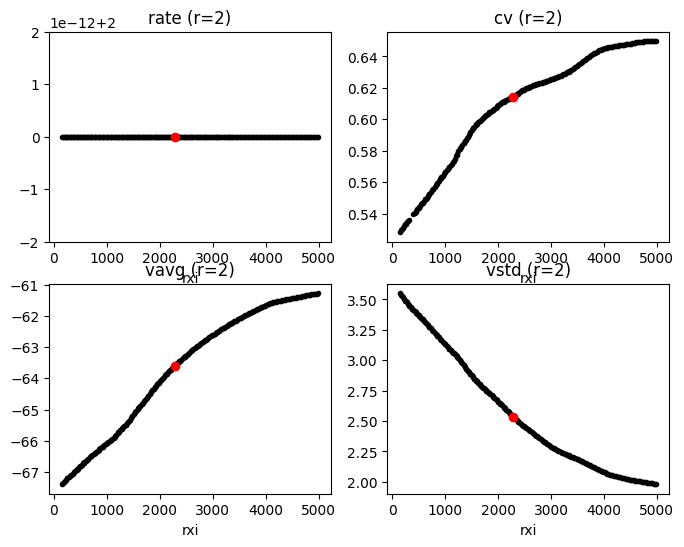

In [24]:
from scipy.interpolate import RegularGridInterpolator


def upsample_and_smooth(da, coords_new, win):
    """Upsample and smooth while preserving the original NaN mask footprint. """
    da_up = da.interp(**coords_new)

    mask0 = da.notnull()
    mask_up = (
        mask0.astype(float)
        .interp(**coords_new, method='nearest')
        .astype(bool)
    )

    num = da_up.fillna(0).rolling(**win, center=True, min_periods=1).sum()
    den = da_up.notnull().astype(float).rolling(**win, center=True, min_periods=1).sum()

    out = num / den
    out = out.where(mask_up)
    return out


def find_contour(da, level, xname, yname):
    """Find and concatenate all contour segments. """
    x = da.coords[xname].values
    y = da.coords[yname].values
    Z = np.ma.masked_invalid(da.transpose(yname, xname).values)

    Xg, Yg = np.meshgrid(x, y)

    fig, ax = plt.subplots()
    cs = ax.contour(Xg, Yg, Z, levels=[level])
    plt.close(fig)

    segs = [seg for seg in cs.allsegs[0] if len(seg) > 0]
    pts = np.vstack(segs)
    seg_id = np.concatenate([np.full(len(seg), i) for i, seg in enumerate(segs)])

    return {
        'xy': pts,
        xname: pts[:, 0],
        yname: pts[:, 1],
        'seg_id': seg_id,
    }


def interp_on_points(da, pts, xname, yname):
    """Interpolate a variable on arbitrary points. """
    x = da.coords[xname].values
    y = da.coords[yname].values
    Z = np.asarray(da.transpose(yname, xname).values, dtype=float)

    interp = RegularGridInterpolator(
        (y, x), Z,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    return interp(np.c_[pts[:, 1], pts[:, 0]])


def split_by_seg(arr, seg_id):
    """Split a contour-aligned array into contour segments. """
    return [arr[seg_id == i] for i in np.unique(seg_id)]


pop = pops_used[0]
r0 = 2
n_grid = 200
smooth_window = 71
interp_2d = 'bicubic'

vars_used = ['rate', 'cv', 'vmin', 'vmax', 'vavg', 'vstd']
vars_2d = [
    ('Firing rate (Hz)', 'rate'),
    ('CV', 'cv'),
    ('Vavg', 'vavg'),
    ('Vstd', 'vstd'),
]
vars_1d = [
    (f'rate (r={r0})', 'rate'),
    (f'cv (r={r0})', 'cv'),
    (f'vavg (r={r0})', 'vavg'),
    (f'vstd (r={r0})', 'vstd'),
]

X_pop = X[pop]

k = 1

# Compute coordinate bounds
x0 = float(X_pop[xname].min()) * k
x1 = float(X_pop[xname].max()) * k
y0 = float(X_pop[yname].min()) * k
y1 = float(X_pop[yname].max()) * k

# Build upsampled grid
coords_new = {
    xname: np.linspace(x0, x1, n_grid),
    yname: np.linspace(y0, y1, n_grid),
}

# Define smoothing window
win = {xname: smooth_window, yname: smooth_window}

# Upsample and smooth all variables on the same grid
X_up = {
    v: upsample_and_smooth(X_pop[v], coords_new, win)
    for v in vars_used
}

# Find the r=r0 contour on the upsampled rate map
contour = find_contour(X_up['rate'], r0, xname, yname)

# Sample all variables on the contour points
for v in vars_used:
    contour[v] = interp_on_points(X_up[v], contour['xy'], xname, yname)

# Select contour point
#imax = np.nanargmax(contour['cv'])   # maximal CV
imax = int(len(contour['cv']) / 2)   # midpoint
xmax = contour[xname][imax]
ymax = contour[yname][imax]

# Plot 2D maps with contour and max-CV point
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

q = 1e-3

for ax, (title, v) in zip(axs.ravel(), vars_2d):
    da = X_up[v]

    im = ax.imshow(
        da.transpose(xname, yname).values.T,
        extent=[v * q for v in  (x0, x1, y0, y1)],
        aspect='auto',
        origin='lower',
        interpolation=interp_2d
    )

    for xs, ys in zip(
            split_by_seg(contour[xname], contour['seg_id']),
            split_by_seg(contour[yname], contour['seg_id'])):
        ax.plot(xs * q, ys * q, 'k-', lw=2)

    ax.plot(xmax * q, ymax * q, 'ro')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)

# Label 2D axes
for n in range(2):
    axs[1, n].set_xlabel(xname)
    axs[n, 0].set_ylabel(yname)

# Plot variables along the contour
plt.figure(figsize=(8, 6))

xc = contour[yname]
xc_max = xc[imax]

for n, (title, v) in enumerate(vars_1d):
    plt.subplot(2, 2, n + 1)

    for xs, ys in zip(
            split_by_seg(xc, contour['seg_id']),
            split_by_seg(contour[v], contour['seg_id'])):
        plt.plot(xs, ys, 'k.')

    plt.plot(xc_max, contour[v][imax], 'ro')
    plt.xlabel(yname)
    plt.title(title)

# Store outputs
res = {
    'X_up': X_up,
    'contour': contour,
    'imax': imax,
    'xmax': xmax,
    'ymax': ymax,
    'pars': {
        'pop': pop,
        'r0': r0,
        'n_grid': n_grid,
        'smooth_window': smooth_window,
        'interp_2d': interp_2d,
        'vars_used': vars_used,
    }
}

In [ ]:
drxe_sel, rxi_sel = res['xmax'], res['ymax']

rxe_sel = rgn['rxe0'] + (rxi_sel - rgn['rxi0']) / rgn['rxi_rxe_slope'] + drxe_sel
print(f'rxe={rxe_sel:.0f}, rxi={rxi_sel:.0f}')

rxe=3706, rxi=0


In [ ]:
rgn

{'rxe0': 9480, 'rxi0': 0, 'drxe': 9250, 'drxi': 2010, 'rxi_rxe_slope': 0.179}

In [ ]:
k0, k1 = 6812.5, 2.0625
rxi_ = 12.5e3
drxe_ = -8e3
rxe_ = k0 + k1 * rxi_ + drxe_
rxe_

24593.75

### 2D batch (rxe, rxi)

In [3]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/pops_inpsur_newsec_var_rxe_rxi'

#exp_name_sub = '2d_psp_0.5_xsec_soma_soma/exp_it2_wx_psp_0.5_sz_20_20_rxmax_20.0_4.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['IT2']
#exp_label = 'it2'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pv_wx_psp_0.5_sz_20_20_rxmax_15.0_2.5_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
#exp_label = 'pv'

#exp_name_sub = '2d_psp_0.5_xsec_soma_soma/exp_som_wx_psp_0.5_sz_20_20_rxmax_10.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
#exp_label = 'som'

#exp_name_sub = '2d_psp_0.5_xsec_soma_soma/exp_vip_wx_psp_0.5_sz_20_20_rxmax_10.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
#exp_label = 'vip'

#exp_name_sub = '2d_psp_0.5_xsec_soma_soma/exp_ngf_wx_psp_0.5_sz_20_20_rxmax_15.0_3.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']
#exp_label = 'ngf'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_ct_wx_psp_0.5_sz_5_5_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_ct_wx_psp_0.5_sz_20_20_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['CT5A', 'CT5B', 'CT6']
#exp_label = 'ct'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_it5_wx_psp_0.5_sz_5_5_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it5_wx_psp_0.5_sz_20_20_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
pops_used = ['IT5A', 'IT5B']
exp_label = 'it5'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it4_wx_psp_0.5_sz_20_20_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['ITP4', 'ITS4']
#exp_label = 'it4'

#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it6_wx_psp_0.5_sz_20_20_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['IT6']
#exp_label = 'it6'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_pt5b_wx_psp_0.5_sz_5_5_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_pt5b_wx_psp_0.5_sz_20_20_rxmax_25.0_4.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['PT5B']
#exp_label = 'pt5b'

#exp_name_sub = '2d_5x5_psp_0.5_xsec_soma_soma/exp_it3_wx_psp_0.5_sz_5_5_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#exp_name_sub = '2d_20x20_psp_0.5_xsec_soma_soma/exp_it3_wx_psp_0.5_sz_20_20_rxmax_25.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_0_xsec_soma_soma'
#pops_used = ['IT3']
#exp_label = 'it3'


In [4]:
dirpath_res = dirpath_repo_root / 'exp_results' / exp_name
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'rxe': 'rxe', 'rxi': 'rxi'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
#job_idx_xr

vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    #'vavg': 'v_med_avg'
    'vavg': 'v_thresh_avg', 'vstd': 'v_thresh_std'
}

dims_new = list(job_idx_xr.dims) + ['pop']
coords_new = dict(job_idx_xr.coords) | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)

# Iterate over all cells in job_idx_xr
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    if np.isnan(job_id):
        continue
    job_id = int(job_id)

    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    # Load data and assign it to the corresponding slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]
X

<xarray.Dataset> Size: 39kB
Dimensions:  (rxe: 20, rxi: 20, pop: 2)
Coordinates:
  * rxe      (rxe) float64 160B 1.0 1.317e+03 2.632e+03 ... 2.368e+04 2.5e+04
  * rxi      (rxi) float64 160B 1.0 264.1 527.2 ... 4.474e+03 4.737e+03 5e+03
  * pop      (pop) <U4 32B 'IT5A' 'IT5B'
Data variables:
    rate     (rxe, rxi, pop) float64 6kB 0.149 0.08599 0.0 ... 13.29 11.89 9.806
    cv       (rxe, rxi, pop) float64 6kB 0.118 0.3766 nan ... 0.3543 0.3851
    vmin     (rxe, rxi, pop) float64 6kB -72.55 -72.94 -75.52 ... -62.99 -61.88
    vmax     (rxe, rxi, pop) float64 6kB -66.36 -68.32 -70.31 ... -57.18 -57.61
    vavg     (rxe, rxi, pop) float64 6kB -70.28 -70.39 -73.86 ... -59.76 -59.62
    vstd     (rxe, rxi, pop) float64 6kB 1.292 1.11 1.176 ... 2.87 2.779 2.642

IT5A:


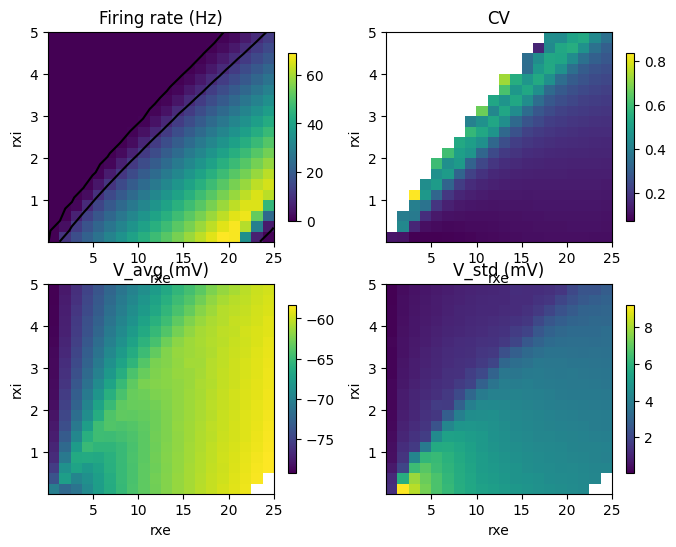

In [5]:
pop = pops_used[0]

def plot_2d_maps(pop):

    r = X['rate'].sel(pop=pop)
    cv = X['cv'].sel(pop=pop)
    vmin = X['vmin'].sel(pop=pop)
    vmax = X['vmax'].sel(pop=pop)
    vavg = X['vavg'].sel(pop=pop)
    vstd = X['vstd'].sel(pop=pop)

    plots = [
        ("Firing rate (Hz)", r),
        ("CV", cv),
        #("Vmin (mV)", vmin),
        #("Vmax (mV)", vmax),
        ("V_avg (mV)", vavg),
        ("V_std (mV)", vstd)
    ]

    k = 1e-3
    x0, x1 = float(r.rxe.min()) * k, float(r.rxe.max()) * k
    y0, y1 = float(r.rxi.min()) * k, float(r.rxi.max()) * k

    fig, axs = plt.subplots(2, 2, figsize=(8, 6))

    for ax, (title, da) in zip(axs.ravel(), plots):
        im = ax.imshow(da.T, extent=(x0, x1, y0, y1),
                    aspect='auto', origin='lower', interpolation='nearest')
        ax.set_title(title)
        ax.set_xlabel('rxe')
        ax.set_ylabel('rxi')
        fig.colorbar(im, ax=ax, shrink=0.8)

    rxi1, rxi2 = r.rxi.item(0), r.rxi.item(-1)
    rxe1 = r.isel(rxi=0).idxmax(dim='rxe').item()
    rxe2 = r.isel(rxi=-1).idxmax(dim='rxe').item()
    q1 = (rxe2 - rxe1) / (rxi2 - rxi1) * 1.1
    q0 = rxe1 - rxi1 * q1

    rxi_ = r.rxi.values
    rxe_ = q0 + rxi_ * q1
    #axs[0, 0].plot(rxe_ * k, rxi_ * k, 'k')

    print(f'{pop}:')
    #print(f'q0 = {q0}')
    #print(f'q1 = {q1}')

    r0 = [0.5, 10]
    for r0_ in r0:
        axs[0, 0].contour(
            r.rxe * k, r.rxi * k, (r - r0_).T,
            [0], colors='k'
        )

plot_2d_maps(pop)

/tmp/ipykernel_328649/852955125.py:32: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cc.collections:


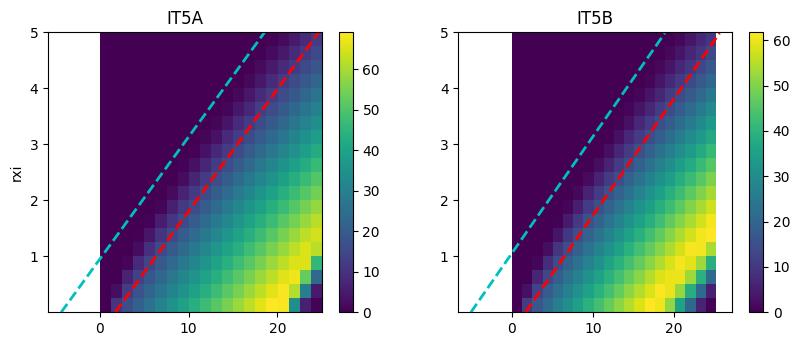

In [7]:
k = 1e-3
x0, x1 = float(X.rxe.min()) * k, float(X.rxe.max()) * k
y0, y1 = float(X.rxi.min()) * k, float(X.rxi.max()) * k

# Contour levels and margins
r0 = [0.5, 10]
marg_l, marg_r = 0.3, 0.1

regions = {}

plt.figure(figsize=(15, 8))

for n, pop in enumerate(pops_used):
    r = X['rate'].sel(pop=pop)

    # 2D rate map
    plt.subplot(2, 3, n + 1)
    plt.imshow(r.T, extent=(x0, x1, y0, y1),
               aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar()
    plt.title(pop)
    if n in [3, 4, 5]:
        plt.xlabel('rxe')
    if n in [0, 3]:
        plt.ylabel('rxi')

    # Contours
    c = []
    cols = ['c', 'r']
    for m, r0_ in enumerate(r0):
        cc = plt.contour(r.rxe * k, r.rxi * k, (r - r0_).T, [0], colors=cols[m])
        for coll in cc.collections:
            coll.set_visible(False)
        cc = cc.allsegs[0]
        try:
            rxe_min_seg = [np.min(c_[:, 0]) for c_ in cc]
        except:
            continue
        seg_id = np.argmin(rxe_min_seg)
        c.append(cc[seg_id])   # if > 1 contours, pick the left one

    # Approximate the high-rate contour with a line
    cc = c[1]
    p1, p2 = np.argmin(cc[:, 0]), np.argmax(cc[:, 0])
    rxe1, rxi1 = cc[p1, 0], cc[p1, 1]
    rxe2, rxi2 = cc[p2, 0], cc[p2, 1]
    q = (rxi2 - rxi1) / (rxe2 - rxe1)
    q = np.round(q, 3).item()

    # Find the distance d0 between the high- and low-rate contours
    rxe_l, rxi_l = c[0][:, 0], c[0][:, 1]
    rxe_r = (rxi_l - rxi1) / q + rxe1
    d0 = np.max(rxe_r - rxe_l)

    # Shift the high-rate contour to the right by a fraction of d0
    d = d0 * (1 + marg_l)
    rxe1 += d0 * marg_r
    rxe2 += d0 * marg_r

    # Start and end of the linearized high-rate contour
    rxi_min, rxi_max = y0, rxi2
    rxe_min = (rxi_min - rxi1) / q + rxe1
    rxe_max = (rxi_max - rxi1) / q + rxe1

    # Cut the high-rate contour by the rxe=0 line
    if rxe_min < 0:
        rxe_min = 0
        rxi_min = rxi1 + q * (rxe_min - rxe1)

    # Plot the resulting parallelogram region
    plt.plot([rxe_min, rxe_max], [rxi_min, rxi_max], 'r--', 
              markersize=8, linewidth=2)
    plt.plot([rxe_min - d, rxe_max - d], [rxi_min, rxi_max], 'c--',
             markersize=8, linewidth=2)

    # Store the region
    p = 10   # precision
    regions[pop] = {
        'rxe0': int(rxe_min / k / p) * p,
        'rxi0': int(rxi_min / k / p) * p,
        'drxe': int(d / k / p) * p,
        'drxi': int((rxi_max - rxi_min) / k / p) * p,
        'rxi_rxe_slope': q,
    }

#plt.xlabel('rxe')

# Collect parameters
par = {
    'exp_name': exp_name,
    'exp_name_sub': exp_name_sub,
    'exp_label': exp_label,
    'pops': pops_used,
    'r_levels': r0,
    'r_margins': [marg_l, marg_r]
}

# Save the result
res = {'regions': regions, 'params': par}
dirpath_out = dirpath_repo_root / 'exp_results' / exp_name / exp_name_sub
fpath_out = dirpath_out / f'regions_{exp_label}.json'
with open(fpath_out, 'w') as fid:
    json.dump(res, fid, indent=4)

#pprint(res)

Text(0.5, 1.0, 'CV, PV2')

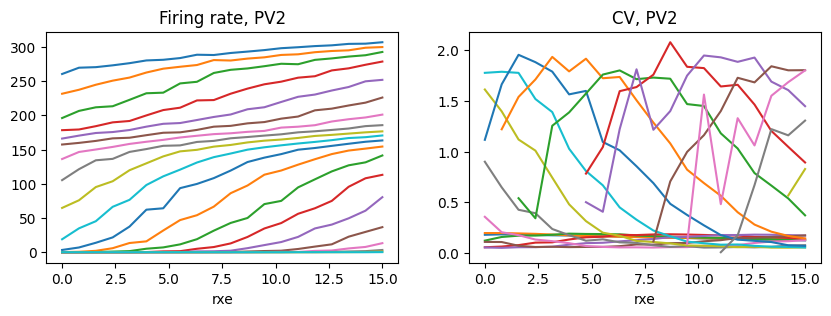

In [27]:
pop = pops_used[0]
rxi = X.rxi.item(0)

r = X['rate'].sel(pop=pop)
cv = X['cv'].sel(pop=pop)
vmin = X['vmin'].sel(pop=pop)
vmax = X['vmax'].sel(pop=pop)
vavg = X['vavg'].sel(pop=pop)

plt.figure(figsize=(10, 3))
for rxi in X.rxi.to_numpy():
    rxi_lbl = np.round(rxi / 1000, 1)
    plt.subplot(1, 2, 1)
    plt.plot(r.rxe / 1000, r.sel(rxi=rxi), label=f'rxi={rxi_lbl}')
    plt.subplot(1, 2, 2)
    plt.plot(r.rxe / 1000, cv.sel(rxi=rxi), label=f'rxi={rxi_lbl}')
    
plt.subplot(1, 2, 1)
plt.xlabel('rxe')
plt.title(f'Firing rate, {pop}')
#plt.legend()
plt.subplot(1, 2, 2)
plt.xlabel('rxe')
plt.title(f'CV, {pop}')
#plt.legend()

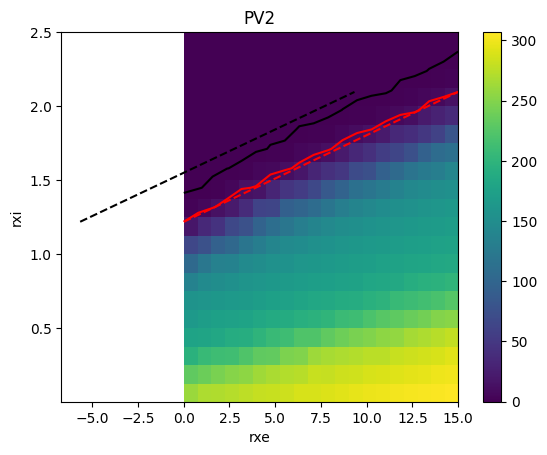

In [26]:
pop = pops_used[0]

k = 1e-3
x0, x1 = float(X.rxe.min()) * k, float(X.rxe.max()) * k
y0, y1 = float(X.rxi.min()) * k, float(X.rxi.max()) * k

r0 = [1, 15]

plt.figure()

r = X['rate'].sel(pop=pop)

plt.imshow(r.T, extent=(x0, x1, y0, y1),
            aspect='auto', origin='lower',
            interpolation='nearest')
plt.colorbar()
plt.title(pop)
plt.xlabel('rxe')
plt.ylabel('rxi')

C = []
cols = ['k', 'r']
for n, r0_ in enumerate(r0):
    c = plt.contour(r.rxe * k, r.rxi * k, (r - r0_).T, [0], colors=cols[n])
    C.append(c)

c = []
for m in range(2):
    cc = C[m].allsegs[0]
    rxe_min_seg = [np.min(c_[:, 0]) for c_ in cc]
    seg_id = np.argmin(rxe_min_seg)
    c.append(cc[seg_id])

cc = c[1]
p1, p2 = np.argmin(cc[:, 0]), np.argmax(cc[:, 0])
rxe1, rxi1 = cc[p1, 0], cc[p1, 1]
rxe2, rxi2 = cc[p2, 0], cc[p2, 1]
q = (rxi2 - rxi1) / (rxe2 - rxe1)

rxe_l, rxi_l = c[0][:, 0], c[0][:, 1]
rxe_r = (rxi_l - rxi1) / q + rxe1
d = np.max(rxe_r - rxe_l) * 1.2

plt.plot([rxe1, rxe2], [rxi1, rxi2], 'r--')
plt.plot([rxe1 - d, rxe2 - d], [rxi1, rxi2], 'k--')

In [ ]:
c = C[1].allsegs[0]
#print(c)
rxe_min_seg = [np.min(c_[:, 0]) for c_ in c]
print(rxe_min_seg)
seg_id = np.argmin(rxe_min_seg)
c = c[seg_id]
print(c)

p1, p2 = np.argmin(c[:, 0]), np.argmax(c[:, 0])
rxe1, rxi1 = c[p1, 0], c[p1, 1]
rxe2, rxi2 = c[p2, 0], c[p2, 1]
print(f'rxe1={rxe1}, rxi1={rxi1}')
print(f'rxe2={rxe2}, rxi2={rxi2}')

[np.float64(1.678218400562028)]
[[4.69018922e+00 1.00000000e-03]
 [5.26389474e+00 4.27619253e-02]
 [6.08092358e+00 1.06210526e-01]
 [6.31647368e+00 1.30927520e-01]
 [7.28140087e+00 2.11421053e-01]
 [7.36905263e+00 2.21187787e-01]
 [8.42163158e+00 2.78627923e-01]
 [9.03684394e+00 3.16631579e-01]
 [9.47421053e+00 3.55548101e-01]
 [1.05267895e+01 4.14288026e-01]
 [1.06922430e+01 4.21842105e-01]
 [1.15793684e+01 4.76109180e-01]
 [1.24870756e+01 5.27052632e-01]
 [1.26319474e+01 5.40024203e-01]
 [1.36845263e+01 6.04035944e-01]
 [1.42000215e+01 6.32263158e-01]
 [1.47371053e+01 6.73522188e-01]
 [1.57896842e+01 7.27185240e-01]
 [1.59838247e+01 7.37473684e-01]
 [1.68422632e+01 8.36181346e-01]
 [1.69753250e+01 8.42684211e-01]
 [1.73713974e+01 9.47894737e-01]
 [1.68422632e+01 9.78989797e-01]
 [1.57896842e+01 9.96221493e-01]
 [1.47371053e+01 9.86653723e-01]
 [1.36845263e+01 9.98072065e-01]
 [1.26319474e+01 1.04074396e+00]
 [1.15793684e+01 1.03585530e+00]
 [1.05267895e+01 1.00430354e+00]
 [9.7030584

In [ ]:
# extract contour segments from QuadContourSet `c`
contour_points = {
    float(level): [np.asarray(seg) for seg in segs]
    for level, segs in zip(c.levels, c.allsegs)
}

# optional: stacked arrays per level (all segments concatenated)
contour_points_stacked = {
    lvl: (np.vstack(segs) if len(segs) else np.empty((0, 2)))
    for lvl, segs in contour_points.items()
}

# inspect
list(contour_points.keys()), {lvl: [s.shape for s in segs] for lvl, segs in contour_points.items()}

AttributeError: 'numpy.ndarray' object has no attribute 'levels'

### Stuff

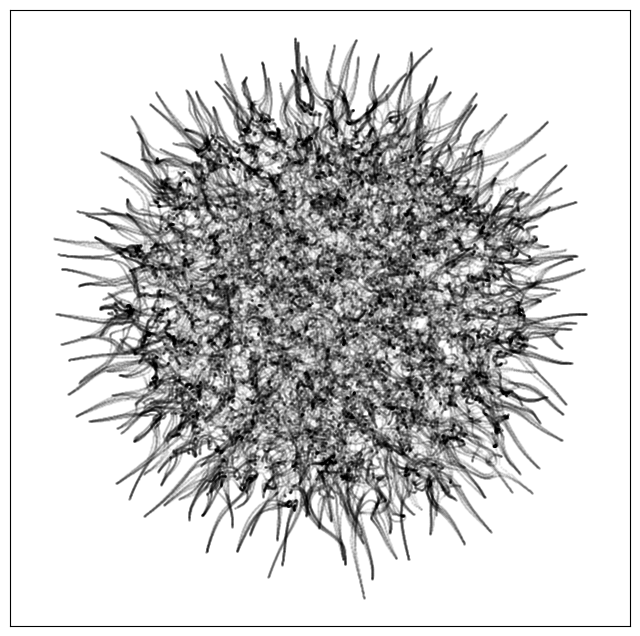

In [53]:
from numpy.random import randn

N = 200   # matrix size
M = 300   # num. of interpolation steps

K = 5    # num. of random perturbation
d = 0.07   # perturbation amplitude

sz = (N, N)
X1 = randn(*sz) + 1j * randn(*sz)
X2 = randn(*sz) + 1j * randn(*sz)

dX = randn(*sz, K) + 1j * randn(*sz, K)

L = []
for m in range(M):
    a = m / M
    r = 1 - 4 * (a - 0.5)**2
    for k in range(K):
        X = a * X1 + (1 - a) * X2 + d * dX[:, :, k] * r
        #X = a * (X1 + d * dX[:, :, k]) + (1 - a) * X2
        L.append(np.linalg.eigvals(X))
L = np.asarray(L).ravel()

plt.figure(figsize=(8, 8))
plt.plot(np.real(L), np.imag(L), 'k.', alpha=0.05, markersize=2)
plt.axis('equal')
s = 4
#plt.xlim(-s, s)
#plt.ylim(-s, s)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()